In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

os.environ.setdefault("DJANGO_SETTINGS_MODULE", "config.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

import django
django.setup()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from data_engine.models.stock_titulo_deuda import StockTituloDeuda, Instrumento, Tenedor

In [3]:
qs = StockTituloDeuda.objects.tenedores_reales().filter(
    instrumento=Instrumento.BONOS_GOBIERNO_GENERAL
).values("anio", "trimestre", "fecha_corte", "tenedor", "monto_miles_millones_clp")

df_holders = pd.DataFrame(qs)
df_holders["monto_miles_millones_clp"] = df_holders["monto_miles_millones_clp"].astype(float)
df_holders.head()

,anio,trimestre,fecha_corte,tenedor,monto_miles_millones_clp
0,2008,1,2008-03-31,bancos_cooperativas,0.000000
1,2008,2,2008-06-30,bancos_cooperativas,665.944130
2,2008,3,2008-09-30,bancos_cooperativas,774.791105
3,2008,4,2008-12-31,bancos_cooperativas,677.327673
4,2009,1,2009-03-31,bancos_cooperativas,488.464716


In [4]:
pivot_holders = df_holders.pivot_table(
    index="fecha_corte", columns="tenedor", values="monto_miles_millones_clp", aggfunc="sum"
)
pivot_holders = pivot_holders.sort_index()
pivot_holders.tail()

tenedor,bancos_cooperativas,companias_seguros,fondos_mutuos_inversion,fondos_pensiones,gobierno_general,inversionistas_extranjeros,otros_intermediarios_financieros,otros_sectores_residentes
fecha_corte,,,,,,,,
2025-03-31,22988.460449,2514.919898,4592.509851,45015.842919,0.0,51294.978231,246.115502,1808.524424
2025-06-30,25615.841217,2614.818586,5488.222660,46386.849748,0.0,53037.055907,368.889741,1808.639964
2025-09-30,25414.029105,2700.402156,5837.444723,45772.880403,0.0,57884.642156,284.895269,2072.566841
2025-12-31,23328.811382,2907.298092,5297.863858,45388.192753,0.0,58530.357548,505.119504,1983.962209
2026-03-31,25149.875614,2831.590090,5252.227257,45571.616924,0.0,62969.211040,392.681365,1959.534954


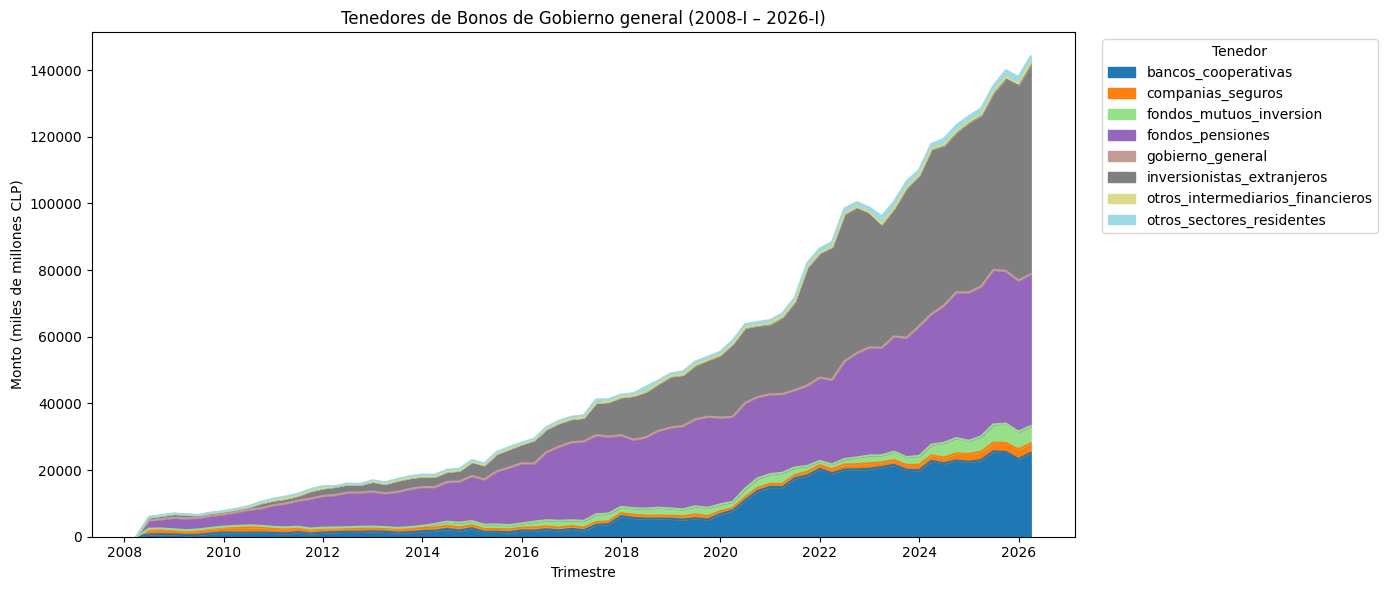

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
pivot_holders.plot.area(ax=ax, cmap="tab20")

ax.set_title("Tenedores de Bonos de Gobierno general (2008-I – 2026-I)")
ax.set_xlabel("Trimestre")
ax.set_ylabel("Monto (miles de millones CLP)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Tenedor")

plt.tight_layout()
plt.show()

In [6]:
pivot_holders_pct = pivot_holders.div(pivot_holders.sum(axis=1), axis=0) * 100
pivot_holders_pct.tail()

tenedor,bancos_cooperativas,companias_seguros,fondos_mutuos_inversion,fondos_pensiones,gobierno_general,inversionistas_extranjeros,otros_intermediarios_financieros,otros_sectores_residentes
fecha_corte,,,,,,,,
2025-03-31,17.895235,1.957725,3.575013,35.042324,0.0,39.930281,0.191587,1.407835
2025-06-30,18.929782,1.932318,4.055727,34.279294,0.0,39.193712,0.272605,1.336562
2025-09-30,18.157176,1.929315,4.170591,32.702656,0.0,41.355962,0.203545,1.480755
2025-12-31,16.912092,2.107630,3.840657,32.903918,0.0,42.431257,0.366184,1.438262
2026-03-31,17.449833,1.964653,3.644173,31.619128,0.0,43.690166,0.272456,1.359592


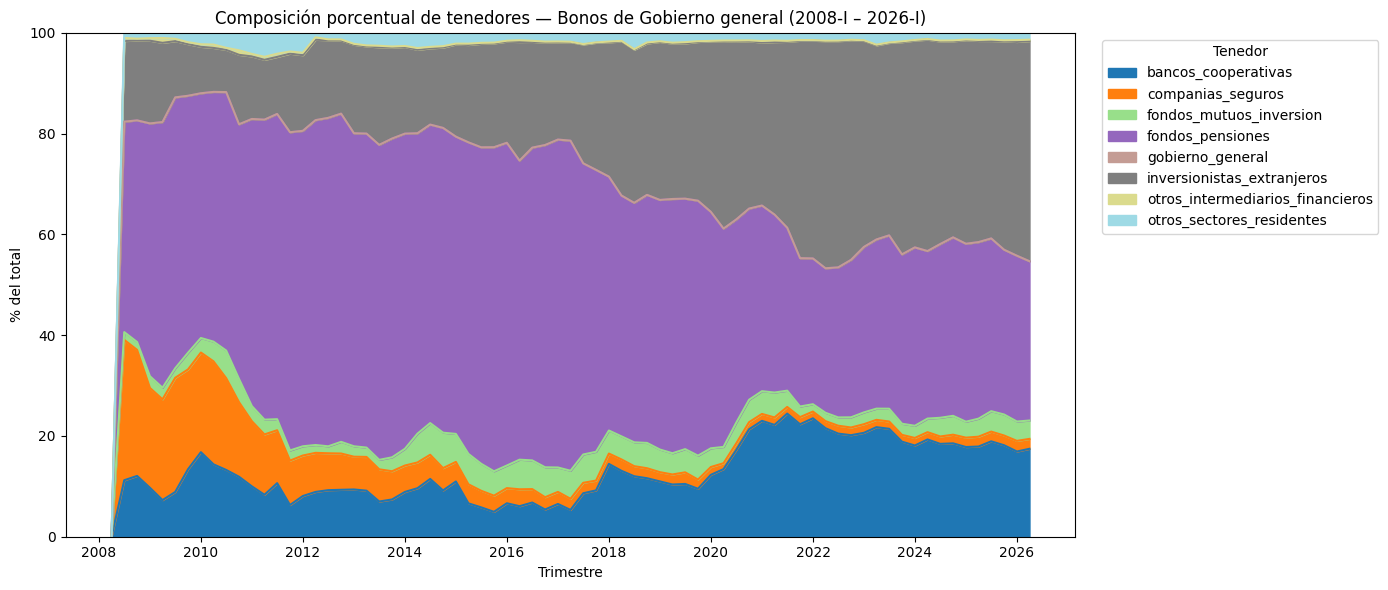

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
pivot_holders_pct.plot.area(ax=ax, cmap="tab20")

ax.set_title("Composición porcentual de tenedores — Bonos de Gobierno general (2008-I – 2026-I)")
ax.set_xlabel("Trimestre")
ax.set_ylabel("% del total")
ax.set_ylim(0, 100)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Tenedor")

plt.tight_layout()
plt.show()

In [ ]:
qs_bc = StockTituloDeuda.objects.tenedores_reales().filter(
    instrumento=Instrumento.BONOS_BANCO_CENTRAL
).values("fecha_corte", "tenedor", "monto_miles_millones_clp")

df_holders_bc = pd.DataFrame(qs_bc)
df_holders_bc["monto_miles_millones_clp"] = df_holders_bc["monto_miles_millones_clp"].astype(float)

pivot_holders_bc = df_holders_bc.pivot_table(
    index="fecha_corte", columns="tenedor", values="monto_miles_millones_clp", aggfunc="sum"
).sort_index()

pivot_holders_bc_pct = pivot_holders_bc.div(pivot_holders_bc.sum(axis=1), axis=0) * 100

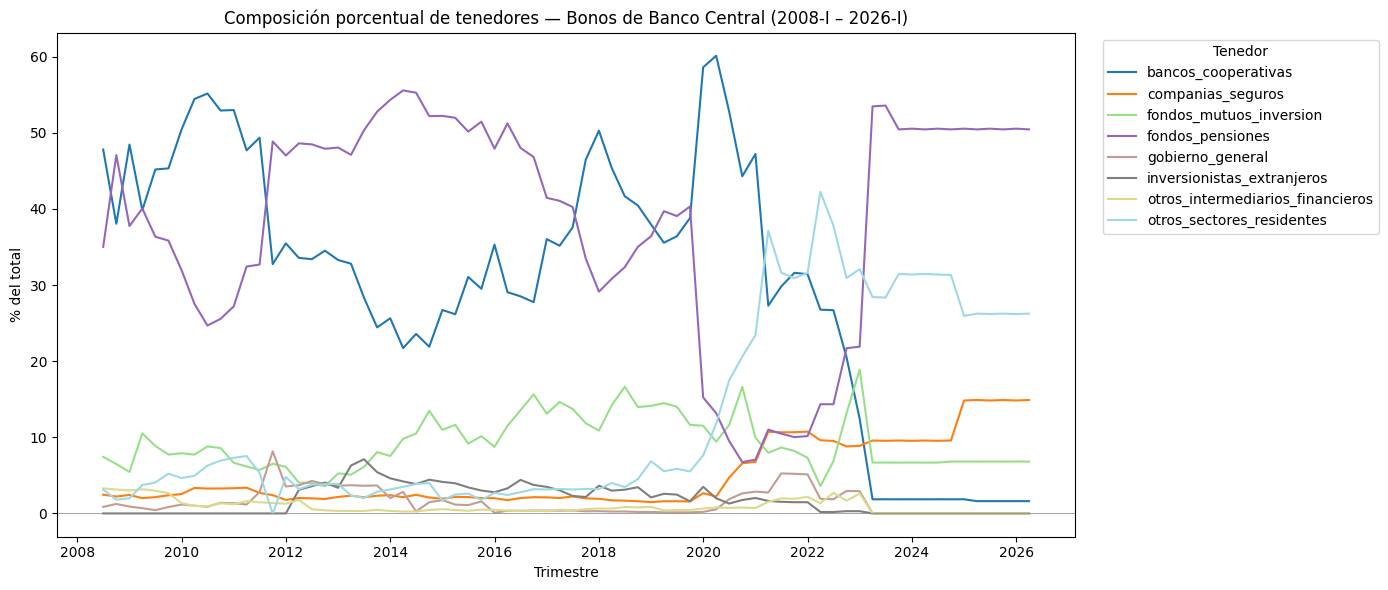

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
pivot_holders_bc_pct.plot.line(ax=ax, cmap="tab20")

ax.set_title("Composición porcentual de tenedores — Bonos de Banco Central (2008-I – 2026-I)")
ax.set_xlabel("Trimestre")
ax.set_ylabel("% del total")
ax.axhline(0, color="gray", linewidth=0.5)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Tenedor")

plt.tight_layout()
plt.show()

In [11]:
print(pivot_holders_bc["otros_sectores_residentes"].describe())
print()
print(pivot_holders_bc[pivot_holders_bc["otros_sectores_residentes"] < 0])

count     73.000000
mean     272.555377
std      171.411648
min       -5.339517
25%      138.813860
50%      310.421556
75%      384.700537
max      613.286809
Name: otros_sectores_residentes, dtype: float64

tenedor      bancos_cooperativas  companias_seguros  fondos_mutuos_inversion  \
fecha_corte                                                                    
2011-09-30           3523.707113          258.53155                702.65287   

tenedor      fondos_pensiones  gobierno_general  inversionistas_extranjeros  \
fecha_corte                                                                   
2011-09-30        5256.633143        876.987431                         0.0   

tenedor      otros_intermediarios_financieros  otros_sectores_residentes  
fecha_corte                                                               
2011-09-30                         147.428818                  -5.339517  
